# MMAR Analysis of VIX Data

Multifractal Model of Asset Returns (MMAR) applied to VIX.

## Pipeline
1. Load data & compute cumulative log returns X(t)
2. Partition function S_q(T, Δt)
3. Scaling function τ(q) via OLS
4. Multifractal spectrum f(α) via Legendre transform
5. Hurst exponent H from τ(1/H) = 0
6. Cascade parameters λ, σ²
7. MMAR simulation: X(t) = B_H[θ(t)]
8. Monte Carlo + Gaussian benchmark comparison

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import fsolve
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 5)

In [7]:
!pip install fbm --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Step 0: Load Data

Download VIX data from Yahoo Finance (or fall back to local Excel file).

In [8]:
import os

from pathlib import Path

def find_vix_csv():
    """Locate VIX_daily.csv whether the notebook cwd is repo root, Data/, or conference_papers/."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        for rel in ('VIX_daily.csv', Path('Data') / 'VIX_daily.csv'):
            p = base / rel
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VIX_daily.csv not found. Place it in the repo root, in Data/, or next to this notebook. "
        f"Searched upward from {here}"
    )

print('Loading VIX data from local CSV...')
csv_path = find_vix_csv()
print(f'  File: {csv_path}')
df = pd.read_csv(csv_path, parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date', ascending=True).reset_index(drop=True)
df = df.dropna(subset=['Last Price'])
df = df[['Last Price']].copy()

print(f'Loaded {len(df)} observations')
print(f'Price range: {df["Last Price"].min():.2f} to {df["Last Price"].max():.2f}')
df.head()

Loading VIX data from local CSV...
  File: /Users/georgeurumov/Library/Mobile Documents/com~apple~CloudDocs/PhD/Data/VIX_daily.csv
Loaded 8136 observations
Price range: 9.14 to 82.69


,Last Price
0,17.24
1,18.19
2,19.22
3,20.11
4,20.26


## Step 1: Cumulative Log Returns X(t)

Theory (Eq. 3.1.5): X(t) = ln(P(t)) - ln(P(0))

In [9]:
df['LN_Price'] = np.log(df['Last Price'])
df['Log_Return'] = df['LN_Price'].diff()
df['Xt_VIX'] = df['LN_Price'] - df['LN_Price'].iloc[0]

print("Basic Statistics:")
print(f"  Mean price:     {df['Last Price'].mean():.4f}")
print(f"  Std price:      {df['Last Price'].std():.4f}")
print(f"  Kurtosis price: {stats.kurtosis(df['Last Price']):.4f}")
print(f"  Mean log return:  {df['Log_Return'].dropna().mean():.6f}")
print(f"  Std log return:   {df['Log_Return'].dropna().std():.6f}")

Basic Statistics:
  Mean price:     19.5265
  Std price:      8.0055
  Kurtosis price: 8.3839
  Mean log return:  0.000025
  Std log return:   0.067372


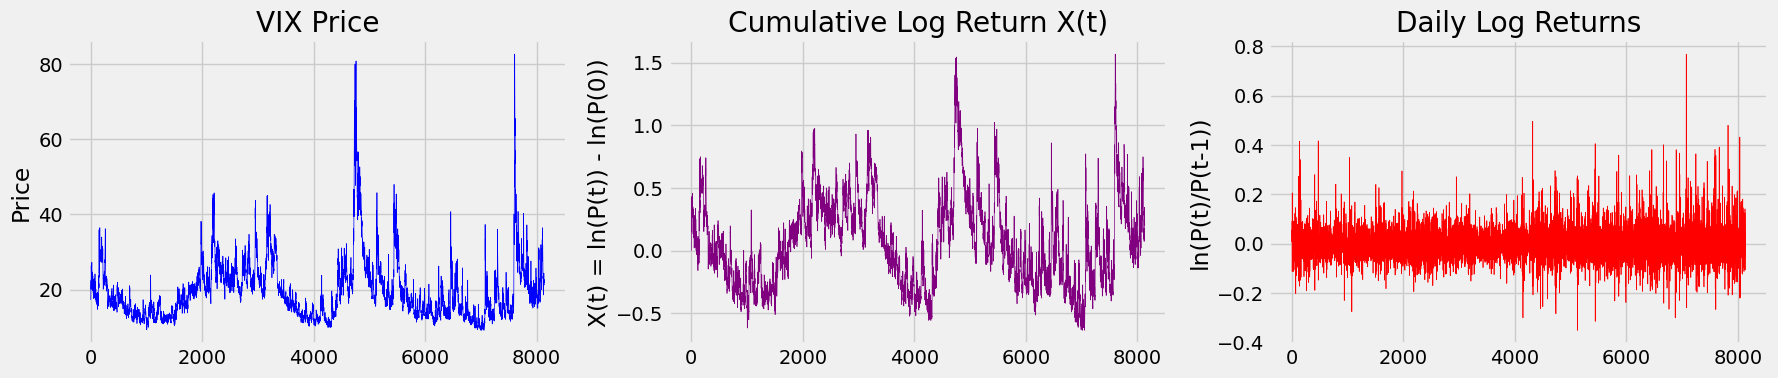

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(df['Last Price'], color='blue', linewidth=0.5)
axes[0].set_title('VIX Price')
axes[0].set_ylabel('Price')

axes[1].plot(df['Xt_VIX'], color='purple', linewidth=0.5)
axes[1].set_title('Cumulative Log Return X(t)')
axes[1].set_ylabel('X(t) = ln(P(t)) - ln(P(0))')

axes[2].plot(df['Log_Return'], color='red', linewidth=0.5)
axes[2].set_title('Daily Log Returns')
axes[2].set_ylabel('ln(P(t)/P(t-1))')

plt.tight_layout()
plt.show()

## Normality Tests

In [11]:
log_returns = df['Log_Return'].dropna().values

ks_stat, ks_pval = stats.kstest(log_returns, 'norm', args=(log_returns.mean(), log_returns.std()))
print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p-value={ks_pval:.6f}")

if len(log_returns) <= 5000:
    sw_stat, sw_pval = stats.shapiro(log_returns)
    print(f"Shapiro-Wilk test:       statistic={sw_stat:.4f}, p-value={sw_pval:.6f}")
else:
    print(f"Shapiro-Wilk test: skipped (n={len(log_returns)} > 5000)")

print(f"\nKurtosis of log returns: {stats.kurtosis(log_returns):.4f}")
print("(Excess kurtosis > 0 indicates fat tails, inconsistent with normality)")

Kolmogorov-Smirnov test: statistic=0.0673, p-value=0.000000
Shapiro-Wilk test: skipped (n=8135 > 5000)

Kurtosis of log returns: 6.3976
(Excess kurtosis > 0 indicates fat tails, inconsistent with normality)


## Step 2: Define q Values and Time Scales

Choose moment orders q and time increment sizes Δt.
Mandelbrot (1997) used 99 values of q between 0.01 and 30.

In [12]:
T = len(df)
print(f"Total observations T = {T}")

def get_factors(n):
    """Return all factors of n, sorted ascending."""
    factors = []
    for i in range(1, n + 1):
        if n % i == 0:
            factors.append(i)
    return tuple(factors)

delta_t = get_factors(T)
print(f"Number of time scales (factors of {T}): {len(delta_t)}")
print(f"Time scales: {delta_t[:10]}... {delta_t[-3:]}")

q = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
     1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9,
     2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9,
     3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9,
     4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9,
     5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9,
     6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9,
     7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9,
     8.0, 8.5, 9.0, 9.5, 10, 11, 12, 13, 14, 15,
     16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
     26, 27, 28, 29, 30]

max_q = 80

print(f"Number of q values: {len(q)}")
print(f"q range: {q[0]} to {q[-1]}")
print(f"max_q index for tau(q) estimation: {max_q} (q={q[max_q]})")

Total observations T = 8136
Number of time scales (factors of 8136): 24
Time scales: (1, 2, 3, 4, 6, 8, 9, 12, 18, 24)... (2712, 4068, 8136)
Number of q values: 105
q range: 0.01 to 30
max_q index for tau(q) estimation: 80 (q=8.0)


## Step 3: Partition Function

S_q(T, Δt) = Σ |X((i+1)Δt) - X(iΔt)|^q

Uses |diff|^q — negative differences are valid (price declines).

In [13]:
def partition_function(SIGMA, DELTA, XT, Q):
    """Compute the partition function S_q(T, delta_t) for all q and delta_t."""
    print("Calculating the partition function...")
    print("This will take a while...\n")
    XT = XT.dropna().reset_index(drop=True)
    SIGMA = [[0 for x in range(len(DELTA))] for y in range(len(Q))]
    for k in range(0, len(Q)):
        if k % 30 == 0:
            print(f"  calculating q index {k} out of {len(Q)-1}")
        for j in range(0, len(DELTA)):
            for i in range(0, len(XT) - 1):
                if i < int(len(XT) / DELTA[j]):
                    idx_end = i * DELTA[j] + DELTA[j]
                    idx_start = i * DELTA[j]
                    if idx_end < len(XT):
                        SIGMA[k][j] += abs(XT[idx_end] - XT[idx_start]) ** Q[k]

    SIGMA = pd.DataFrame(SIGMA)
    for i in range(0, len(Q)):
        SIGMA.rename(index={SIGMA.index[i]: Q[i]}, inplace=True)
    for i in range(len(DELTA) - 1, -1, -1):
        SIGMA.rename(columns={SIGMA.columns[i]: DELTA[i]}, inplace=True)

    print("\nDone! Partition function ready.")
    return SIGMA

print("Partition function defined.")

Partition function defined.


In [14]:
partition_VIX = partition_function([[]], delta_t, df['Xt_VIX'], q)

Calculating the partition function...
This will take a while...

  calculating q index 0 out of 104
  calculating q index 30 out of 104
  calculating q index 60 out of 104
  calculating q index 90 out of 104

Done! Partition function ready.


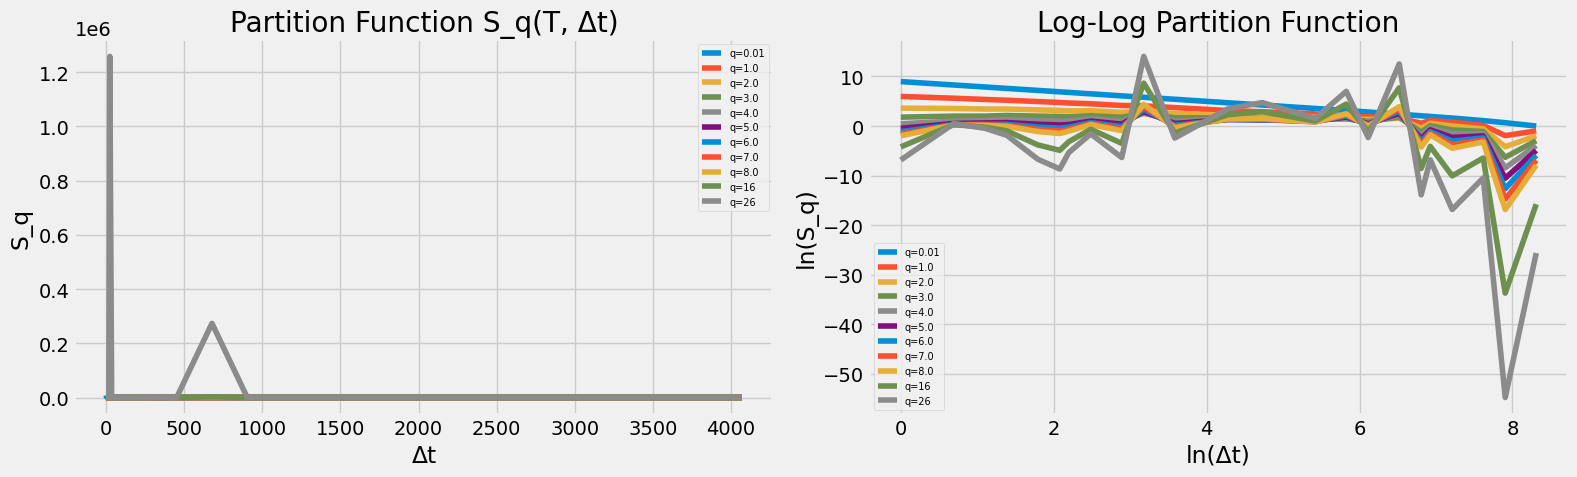

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(0, len(q), 10):
    vals = partition_VIX.iloc[i]
    vals_positive = vals[vals > 0]
    if len(vals_positive) > 0:
        axes[0].plot(vals_positive.index, vals_positive.values, label=f'q={q[i]}')
axes[0].set_title('Partition Function S_q(T, Δt)')
axes[0].set_xlabel('Δt')
axes[0].set_ylabel('S_q')
axes[0].legend(fontsize=7)

for i in range(0, len(q), 10):
    vals = partition_VIX.iloc[i]
    vals_positive = vals[vals > 0]
    if len(vals_positive) > 0:
        axes[1].plot(np.log(vals_positive.index), np.log(vals_positive.values), label=f'q={q[i]}')
axes[1].set_title('Log-Log Partition Function')
axes[1].set_xlabel('ln(Δt)')
axes[1].set_ylabel('ln(S_q)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 4: Scaling Function τ(q)

ln(S_q(T, Δt)) = τ̂(q)·ln(Δt) + ĉ(q)·ln(T)

OLS regression for each q; the coefficient on ln(Δt) is τ(q).

In [16]:
tau_regression = pd.DataFrame(np.log(delta_t))
tau_regression['LN_DELTA'] = pd.DataFrame(np.log(delta_t))
tau_regression['LN_T'] = [np.log(T) for x in range(len(delta_t))]

def scaling_function(TAU_Q, PARTITION, Q):
    """Estimate tau(q) from the partition function via OLS."""
    TAU_Q = [0 for x in range(len(Q))]
    for i in range(0, len(Q)):
        endog_vals = np.log(list(PARTITION.iloc[i] / PARTITION[1][Q[i]]))
        endog_vals = [x if np.isfinite(x) else np.nan for x in endog_vals]
        result = sm.OLS(
            endog=endog_vals,
            exog=tau_regression[['LN_DELTA', 'LN_T']],
            missing='drop'
        ).fit()
        TAU_Q[i] = result.params['LN_DELTA']
    TAU_Q = pd.DataFrame(TAU_Q)
    return TAU_Q

print("Scaling function defined.")

Scaling function defined.


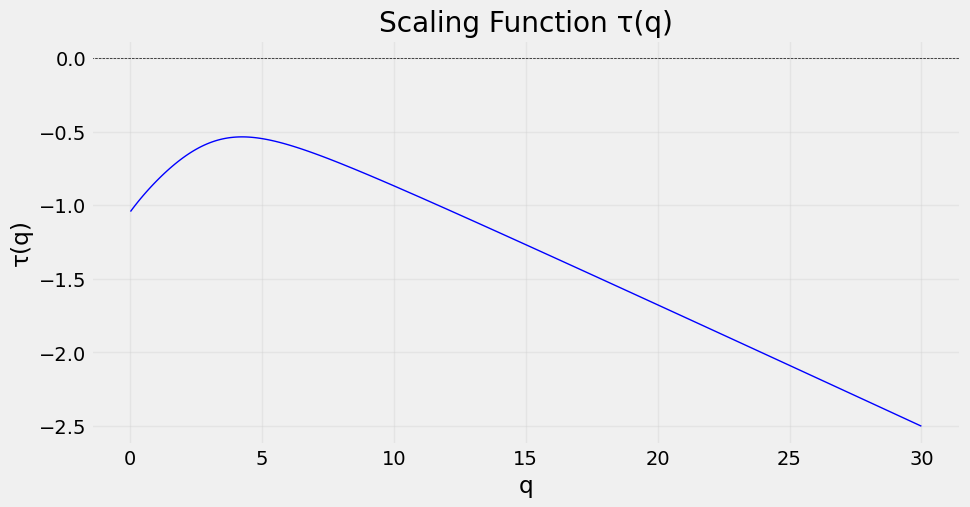

τ(q) at q=1: -0.8352
τ(q) at q=2: -0.6780


In [17]:
tau_q_VIX = scaling_function([], partition_VIX, q)

plt.figure(figsize=(10, 5))
plt.plot(q, tau_q_VIX.values, 'b-', linewidth=1)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.title('Scaling Function τ(q)')
plt.xlabel('q')
plt.ylabel('τ(q)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"τ(q) at q=1: {tau_q_VIX.iloc[10][0]:.4f}")
print(f"τ(q) at q=2: {tau_q_VIX.iloc[20][0]:.4f}")

## Step 5: Hurst Exponent H

τ(1/H) = 0 ⟹ H = 1/q* where q* is the root of τ(q) = 0.

Fit quadratic to τ(q), solve for root, take reciprocal.

In [18]:
def estimate_H(TAU_Q, Q, MIN_Q, MAX_Q):
    """Estimate Hurst exponent: fit quadratic to tau(q), find root, H = 1/root."""
    TAU_Q_ESTIMATED = np.polyfit(Q[MIN_Q:MAX_Q], TAU_Q[MIN_Q:MAX_Q], 2)

    a_coeff = TAU_Q_ESTIMATED[0][0] if hasattr(TAU_Q_ESTIMATED[0], '__len__') else TAU_Q_ESTIMATED[0]
    b_coeff = TAU_Q_ESTIMATED[1][0] if hasattr(TAU_Q_ESTIMATED[1], '__len__') else TAU_Q_ESTIMATED[1]
    c_coeff = TAU_Q_ESTIMATED[2][0] if hasattr(TAU_Q_ESTIMATED[2], '__len__') else TAU_Q_ESTIMATED[2]

    def f(x):
        return a_coeff * x**2 + b_coeff * x + c_coeff

    temp = fsolve(f, [0, 4])
    positive_roots = [r for r in temp if r > 0]
    if not positive_roots:
        raise ValueError("No positive root found for tau(q)=0")

    q_star = positive_roots[0]
    H = 1.0 / q_star
    return H

print("estimate_H defined.")

estimate_H defined.


In [19]:
H_VIX = estimate_H(tau_q_VIX, q, 0, max_q)
print(f"Estimated Hurst exponent H = {H_VIX:.6f}")

if H_VIX <= 0 or H_VIX >= 1:
    print(f"WARNING: H={H_VIX:.4f} is outside valid range (0,1) for fBm.")
    print("This may indicate issues with the data or the estimation range.")

Estimated Hurst exponent H = 0.214349


## Step 6: Multifractal Spectrum f(α)

Legendre transform of τ(q):
f̂(α) = inf_q {q·α − τ̂(q)} + D

Find α₀ where f(α₀) = max f(α) ≈ 1.

In [20]:
def estimate_multifractal_spectrum(TAU_Q, Q, MIN_Q, MAX_Q):
    """Estimate f(alpha) via Legendre transform of tau(q)."""
    TAU_Q_ESTIMATED = np.polyfit(Q[MIN_Q:MAX_Q], TAU_Q[MIN_Q:MAX_Q], 2)

    a = TAU_Q_ESTIMATED[0][0] if hasattr(TAU_Q_ESTIMATED[0], '__len__') else TAU_Q_ESTIMATED[0]
    b = TAU_Q_ESTIMATED[1][0] if hasattr(TAU_Q_ESTIMATED[1], '__len__') else TAU_Q_ESTIMATED[1]
    c = TAU_Q_ESTIMATED[2][0] if hasattr(TAU_Q_ESTIMATED[2], '__len__') else TAU_Q_ESTIMATED[2]

    n_pts = len(Q) - 10
    F_A = [0 for x in range(n_pts)]
    p = [0 for x in range(n_pts)]

    for i in range(0, n_pts):
        p[i] = 2 * a * Q[i] + b
        term = (p[i] - b) / (2 * a)
        F_A[i] = term * p[i] - (a * term**2 + b * term + c)

    F_A = pd.DataFrame(F_A)
    F_A.rename(columns={F_A.columns[0]: 'f(a)'}, inplace=True)
    F_A['p'] = p

    print(f"Estimated tau(q) quadratic: {a:.6f}*q^2 + {b:.6f}*q + {c:.6f}")
    print(f"alpha_0 (Hölder exponent at q=0): {p[0]:.6f}")
    print(f"f(alpha_0): {F_A['f(a)'].iloc[0]:.6f}")

    return F_A

print("estimate_multifractal_spectrum defined.")

estimate_multifractal_spectrum defined.


Estimated tau(q) quadratic: -0.022028*q^2 + 0.207380*q + -1.018801
alpha_0 (Hölder exponent at q=0): 0.206939
f(alpha_0): 1.018798


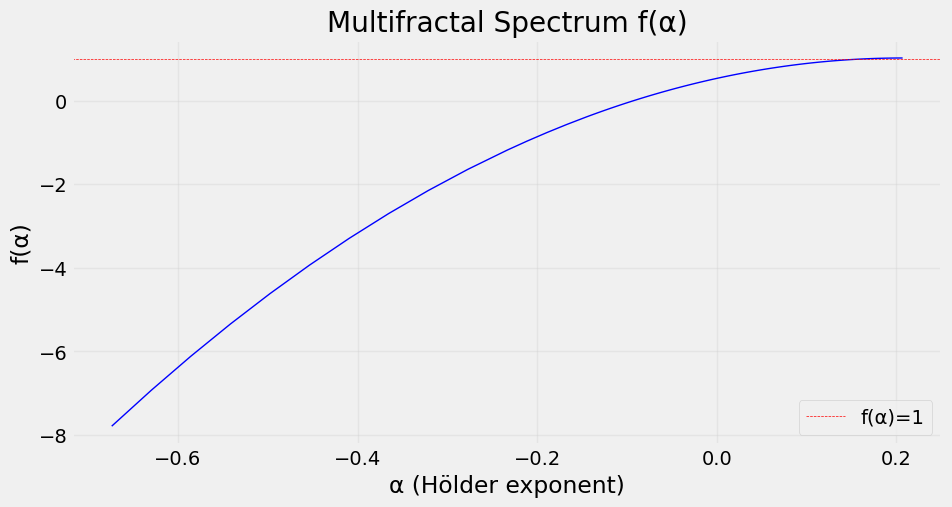

In [21]:
f_a_VIX = estimate_multifractal_spectrum(tau_q_VIX, q, 0, max_q)

plt.figure(figsize=(10, 5))
plt.plot(f_a_VIX['p'], f_a_VIX['f(a)'], 'b-', linewidth=1)
plt.title('Multifractal Spectrum f(α)')
plt.xlabel('α (Hölder exponent)')
plt.ylabel('f(α)')
plt.axhline(y=1, color='r', linestyle='--', linewidth=0.5, label='f(α)=1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 7: Cascade Parameters λ and σ²

λ̂ = α₀ / Ĥ

σ̂² = 2(λ̂ − 1) / ln(b), where b = 2

In [22]:
def lambda_mean(H, ALPHA):
    return ALPHA / H

def sigma_variance(LAMBDA, B):
    return (2 * (LAMBDA - 1)) / np.log(B)

b = 2
alpha_0_VIX = f_a_VIX['p'][0]
lambda_VIX = lambda_mean(H_VIX, alpha_0_VIX)
sigma_VIX = sigma_variance(lambda_VIX, b)

print("=" * 50)
print("MMAR Parameter Estimates for VIX")
print("=" * 50)
print(f"  H (Hurst exponent):   {H_VIX:.6f}")
print(f"  α₀ (Hölder exponent): {alpha_0_VIX:.6f}")
print(f"  λ (cascade mean):     {lambda_VIX:.6f}")
print(f"  σ² (cascade variance):{sigma_VIX:.6f}")
print(f"  b (branching factor):  {b}")
print("=" * 50)

MMAR Parameter Estimates for VIX
  H (Hurst exponent):   0.214349
  α₀ (Hölder exponent): 0.206939
  λ (cascade mean):     0.965431
  σ² (cascade variance):-0.099746
  b (branching factor):  2


## Step 8: Lognormal Cascade + fBm + MMAR

V = −log_b(M) ∼ N(λ, σ²)

Trading time θ(t) = CDF of cascade

X(t) = B_H[θ(t)]

In [23]:
from fbm import FBM

def lognormal_cascade(k, v, ln_lambda, ln_theta):
    """Recursive binomial lognormal cascade."""
    k = k - 1
    m0 = np.random.lognormal(ln_lambda, ln_theta)
    m1 = np.random.lognormal(ln_lambda, ln_theta)
    M = [m0, m1]
    if k >= 0:
        d = [0 for x in range(0, 2)]
        for i in range(0, 2):
            d[i] = lognormal_cascade(k, M[i] * v, ln_lambda, ln_theta)
        v = d
    return v

print("lognormal_cascade defined.")

lognormal_cascade defined.


In [24]:
def MMAR(K, simulated_H, simulated_lambda, simulated_sigma, original_price_history, magnitude_parameter, GRAPHS):
    """MMAR simulation: X(t) = B_H[theta(t)]."""
    h_clamped = max(0.01, min(0.99, simulated_H))
    if h_clamped != simulated_H and GRAPHS:
        print(f"  Note: H clamped from {simulated_H:.4f} to {h_clamped:.4f}")

    sigma_safe = abs(simulated_sigma) if simulated_sigma < 0 else simulated_sigma
    sigma_safe = max(sigma_safe, 1e-6)
    if sigma_safe != simulated_sigma and GRAPHS:
        print(f"  Note: σ² adjusted from {simulated_sigma:.6f} to {sigma_safe:.6f} (must be > 0 for lognormal cascade)")

    new_cascade = list(np.array(
        lognormal_cascade(k=K, v=1, ln_lambda=simulated_lambda, ln_theta=sigma_safe)
    ).flat)

    if GRAPHS:
        plt.figure(figsize=(14, 2))
        plt.title('Binomial Cascade')
        plt.xlabel('Conventional time (days)')
        plt.ylabel('Mass')
        plt.plot(new_cascade, color='crimson', linewidth=0.5)
        plt.show()

    tradingtime = 2**K * np.cumsum(new_cascade) / sum(new_cascade)
    if GRAPHS:
        plt.figure(figsize=(14, 3))
        plt.title('Trading Time θ(t)')
        plt.xlabel('Conventional time (days)')
        plt.ylabel('θ(t)')
        plt.plot(tradingtime, color='orangered')
        plt.show()

    new_fbm_class = FBM(n=10 * 2**K + 1, hurst=h_clamped, length=magnitude_parameter, method='daviesharte')
    new_fbm_simulation = new_fbm_class.fbm()
    if GRAPHS:
        plt.figure(figsize=(14, 2))
        plt.title('Fractional Brownian Motion')
        plt.plot(new_fbm_simulation, color='orange')
        plt.show()

    simulated_xt_array = [0 for x in range(0, len(tradingtime))]
    for i in range(0, len(tradingtime)):
        simulated_xt_array[i] = new_fbm_simulation[int(tradingtime[i] * 10)]

    if GRAPHS:
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        axes[0].set_title('MMAR generated X(t)')
        axes[0].fill_between(range(2**K), simulated_xt_array, color='darkviolet', alpha=0.3)
        axes[1].set_title('MMAR generated Price')
        axes[1].fill_between(range(2**K), original_price_history.iloc[0] * np.exp(simulated_xt_array), color='limegreen', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return simulated_xt_array

print("MMAR function defined.")

MMAR function defined.


## Single MMAR Test Run

Running single MMAR simulation with K=13 (8192 days)
Parameters: H=0.2143, λ=0.9654, σ²=-0.0997
  Note: σ² adjusted from -0.099746 to 0.099746 (must be > 0 for lognormal cascade)


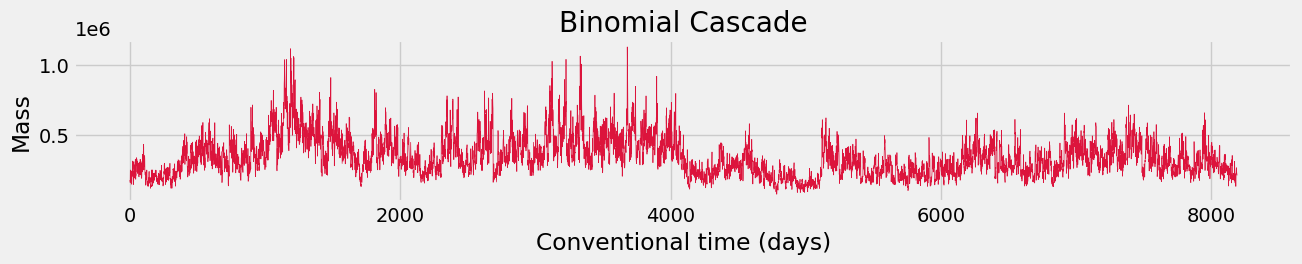

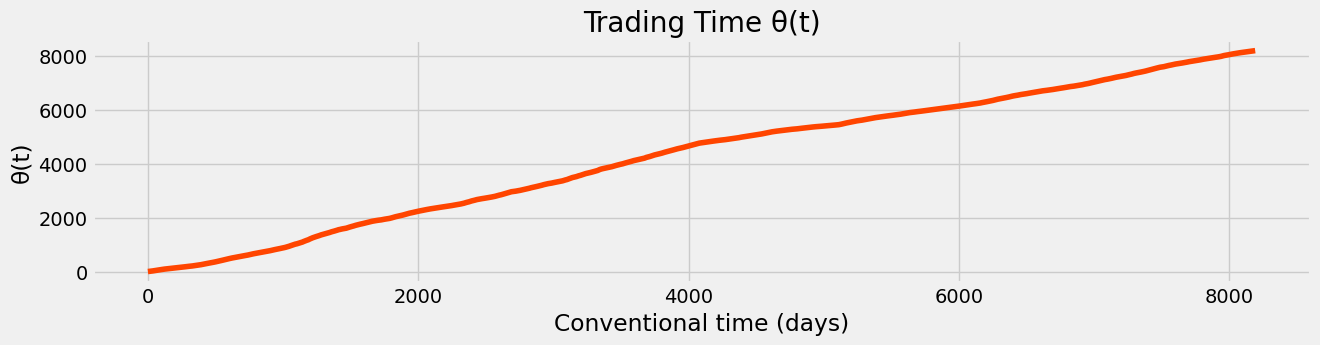

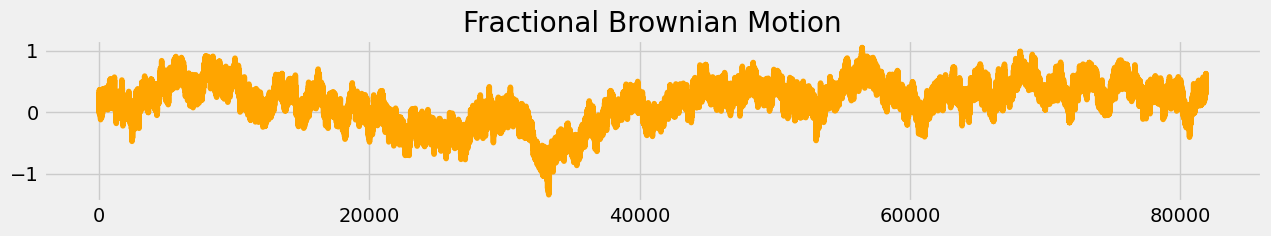

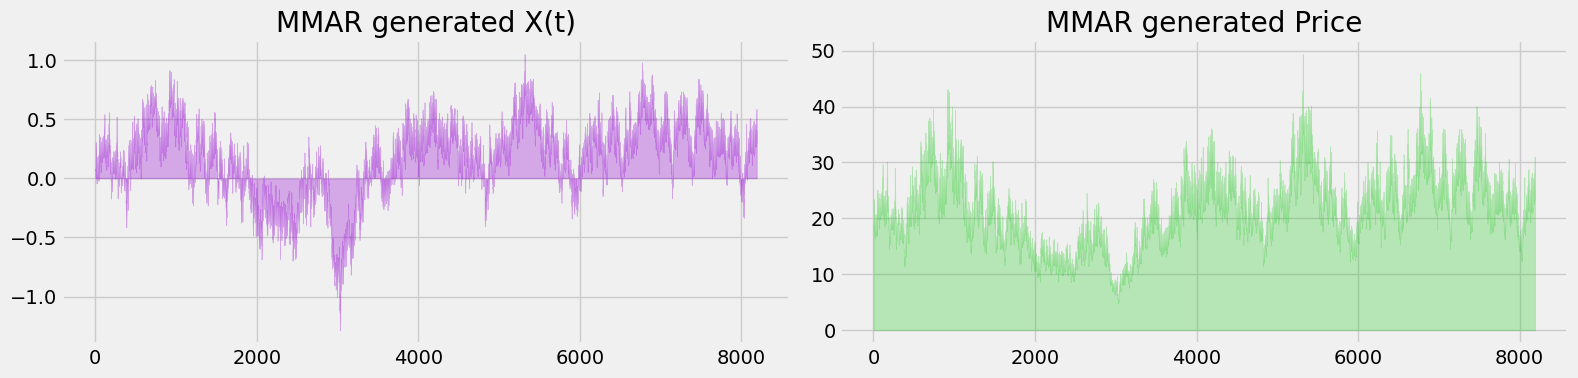

In [25]:
K = 13
magnitude_VIX = 0.15

print(f"Running single MMAR simulation with K={K} ({2**K} days)")
print(f"Parameters: H={H_VIX:.4f}, λ={lambda_VIX:.4f}, σ²={sigma_VIX:.4f}")

test_run = MMAR(K, H_VIX, lambda_VIX, sigma_VIX, df['Last Price'], magnitude_VIX, True)

## Step 9: Monte Carlo MMAR Simulations

Run many MMAR simulations to build the distribution of simulated paths.

In [26]:
attempt_length = 10000
attempt = pd.DataFrame([0 for x in range(0, 2**K)])

print(f"Running {attempt_length} MMAR simulations with K={K}...")
print(f"Each simulation produces {2**K} data points.\n")

for i in range(0, attempt_length):
    if i % 1000 == 0:
        print(f"  Simulation {i}/{attempt_length}")
    attempt[i] = MMAR(K, H_VIX, lambda_VIX, sigma_VIX, df['Last Price'], magnitude_VIX, False)

print(f"\nDone! {attempt_length} MMAR simulations complete.")
attempt.to_csv('VIX_MMAR_attempt.csv')

Running 10000 MMAR simulations with K=13...
Each simulation produces 8192 data points.

  Simulation 0/10000
  Simulation 1000/10000
  Simulation 2000/10000
  Simulation 3000/10000
  Simulation 4000/10000
  Simulation 5000/10000
  Simulation 6000/10000
  Simulation 7000/10000
  Simulation 8000/10000
  Simulation 9000/10000

Done! 10000 MMAR simulations complete.


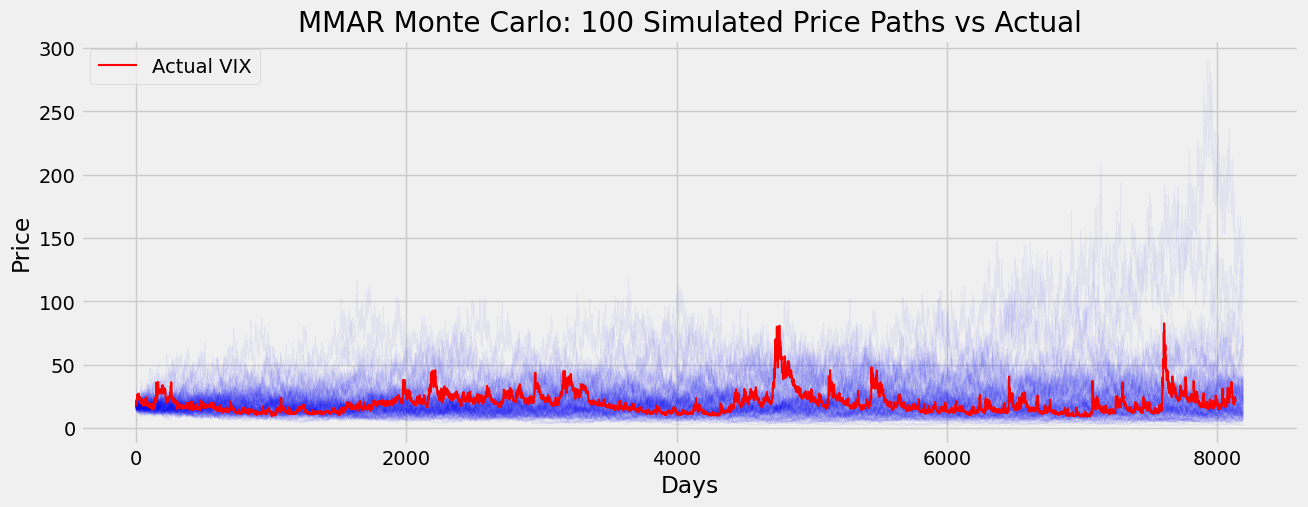

In [27]:
plt.figure(figsize=(14, 5))
for i in range(0, min(attempt_length, 100)):
    plt.plot(df['Last Price'].iloc[0] * np.exp(attempt[i]), alpha=0.05, color='blue', linewidth=0.5)
plt.plot(df['Last Price'].iloc[:2**K].values, color='red', linewidth=1.5, label='Actual VIX')
plt.title(f'MMAR Monte Carlo: {min(attempt_length, 100)} Simulated Price Paths vs Actual')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

In [28]:
diff_attempt = attempt.diff(axis=0).fillna(0)

print("MMAR log return differences computed.")
print(f"  Shape: {diff_attempt.shape}")

MMAR log return differences computed.
  Shape: (8192, 10000)


In [29]:
ks_test_VIX = [0 for x in range(attempt_length)]
log_returns_clean = df['Log_Return'].dropna().values

for i in range(0, attempt_length):
    ks_test_VIX[i] = stats.ks_2samp(diff_attempt[i], log_returns_clean).pvalue

print(f"KS test p-values (MMAR vs actual log returns):")
print(f"  Mean p-value:   {np.mean(ks_test_VIX):.4f}")
print(f"  Median p-value: {np.median(ks_test_VIX):.4f}")
print(f"  % with p>0.05:  {100*np.mean(np.array(ks_test_VIX) > 0.05):.1f}%")

KS test p-values (MMAR vs actual log returns):
  Mean p-value:   0.0000
  Median p-value: 0.0000
  % with p>0.05:  0.0%


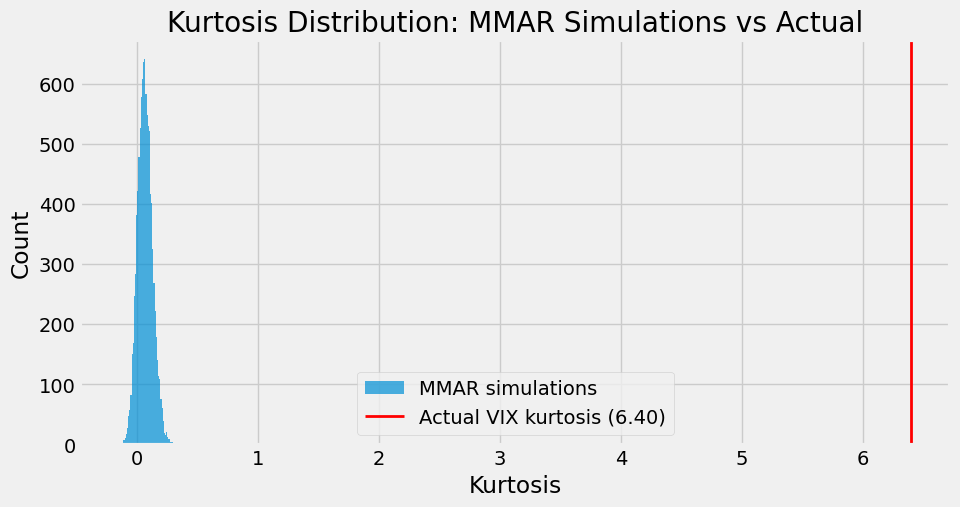

MMAR mean kurtosis: 0.0671
Actual kurtosis:    6.3976


In [30]:
kurtosis_MMAR = stats.kurtosis(diff_attempt, axis=0)
real_kurtosis = stats.kurtosis(log_returns_clean)

plt.figure(figsize=(10, 5))
plt.hist(kurtosis_MMAR, bins=50, alpha=0.7, label='MMAR simulations')
plt.axvline(real_kurtosis, color='red', linewidth=2, label=f'Actual VIX kurtosis ({real_kurtosis:.2f})')
plt.title('Kurtosis Distribution: MMAR Simulations vs Actual')
plt.xlabel('Kurtosis')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f"MMAR mean kurtosis: {np.mean(kurtosis_MMAR):.4f}")
print(f"Actual kurtosis:    {real_kurtosis:.4f}")

## Step 10: Gaussian Benchmark

Compare MMAR with geometric Brownian motion (Gaussian random walk).

In [31]:
Gaussian_length = 1000
n_days = 2**K
log_return_std = df['Log_Return'].dropna().std()
start_price = df['Last Price'].iloc[0]

Gaussian_VIX = pd.DataFrame()

print(f"Running {Gaussian_length} Gaussian simulations...")
for i in range(0, Gaussian_length):
    if i % 200 == 0:
        print(f"  Simulation {i}/{Gaussian_length}")
    prices = [0.0 for x in range(n_days)]
    prices[0] = start_price
    for j in range(1, n_days):
        prices[j] = prices[j - 1] * np.exp(np.random.normal(0, log_return_std))
    Gaussian_VIX[i] = prices

print(f"\nDone! {Gaussian_length} Gaussian simulations complete.")

Running 1000 Gaussian simulations...
  Simulation 0/1000
  Simulation 200/1000
  Simulation 400/1000
  Simulation 600/1000
  Simulation 800/1000

Done! 1000 Gaussian simulations complete.


In [32]:
Gaussian_diff_attempt = pd.DataFrame()
for i in range(0, Gaussian_length):
    log_prices = np.log(Gaussian_VIX[i])
    diffs = [0.0] + [log_prices.iloc[j] - log_prices.iloc[j-1] for j in range(1, n_days)]
    Gaussian_diff_attempt[i] = diffs

print("Gaussian log return differences computed.")

Gaussian log return differences computed.


In [33]:
ks_test_Gaussian_VIX = [0 for x in range(Gaussian_length)]
for i in range(0, Gaussian_length):
    ks_test_Gaussian_VIX[i] = stats.ks_2samp(Gaussian_diff_attempt[i], log_returns_clean).pvalue

print(f"KS test p-values (Gaussian vs actual log returns):")
print(f"  Mean p-value:   {np.mean(ks_test_Gaussian_VIX):.4f}")
print(f"  Median p-value: {np.median(ks_test_Gaussian_VIX):.4f}")
print(f"  % with p>0.05:  {100*np.mean(np.array(ks_test_Gaussian_VIX) > 0.05):.1f}%")

KS test p-values (Gaussian vs actual log returns):
  Mean p-value:   0.0000
  Median p-value: 0.0000
  % with p>0.05:  0.0%


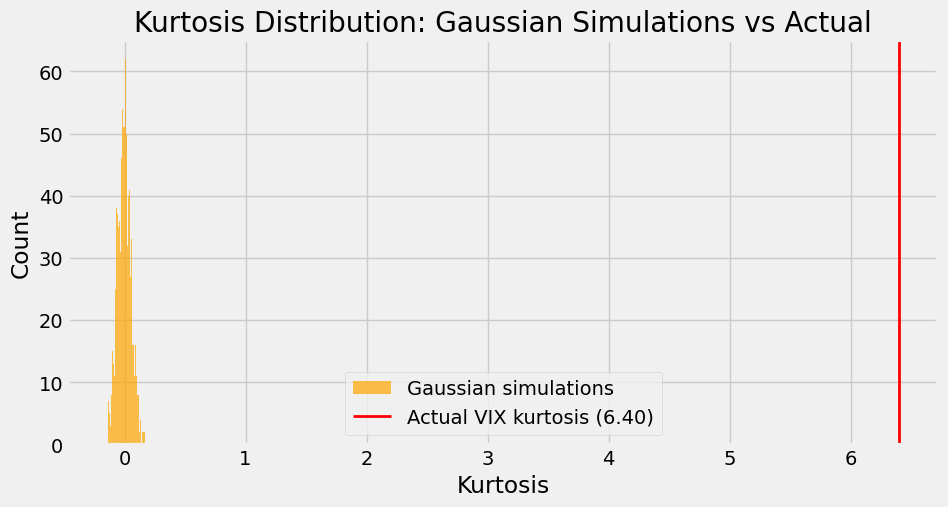

Gaussian mean kurtosis: -0.0030
Actual kurtosis:        6.3976


In [34]:
kurtosis_Gaussian = stats.kurtosis(Gaussian_diff_attempt, axis=0)

plt.figure(figsize=(10, 5))
plt.hist(kurtosis_Gaussian, bins=50, alpha=0.7, color='orange', label='Gaussian simulations')
plt.axvline(real_kurtosis, color='red', linewidth=2, label=f'Actual VIX kurtosis ({real_kurtosis:.2f})')
plt.title('Kurtosis Distribution: Gaussian Simulations vs Actual')
plt.xlabel('Kurtosis')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f"Gaussian mean kurtosis: {np.mean(kurtosis_Gaussian):.4f}")
print(f"Actual kurtosis:        {real_kurtosis:.4f}")

## Step 11: MMAR vs Gaussian Comparison

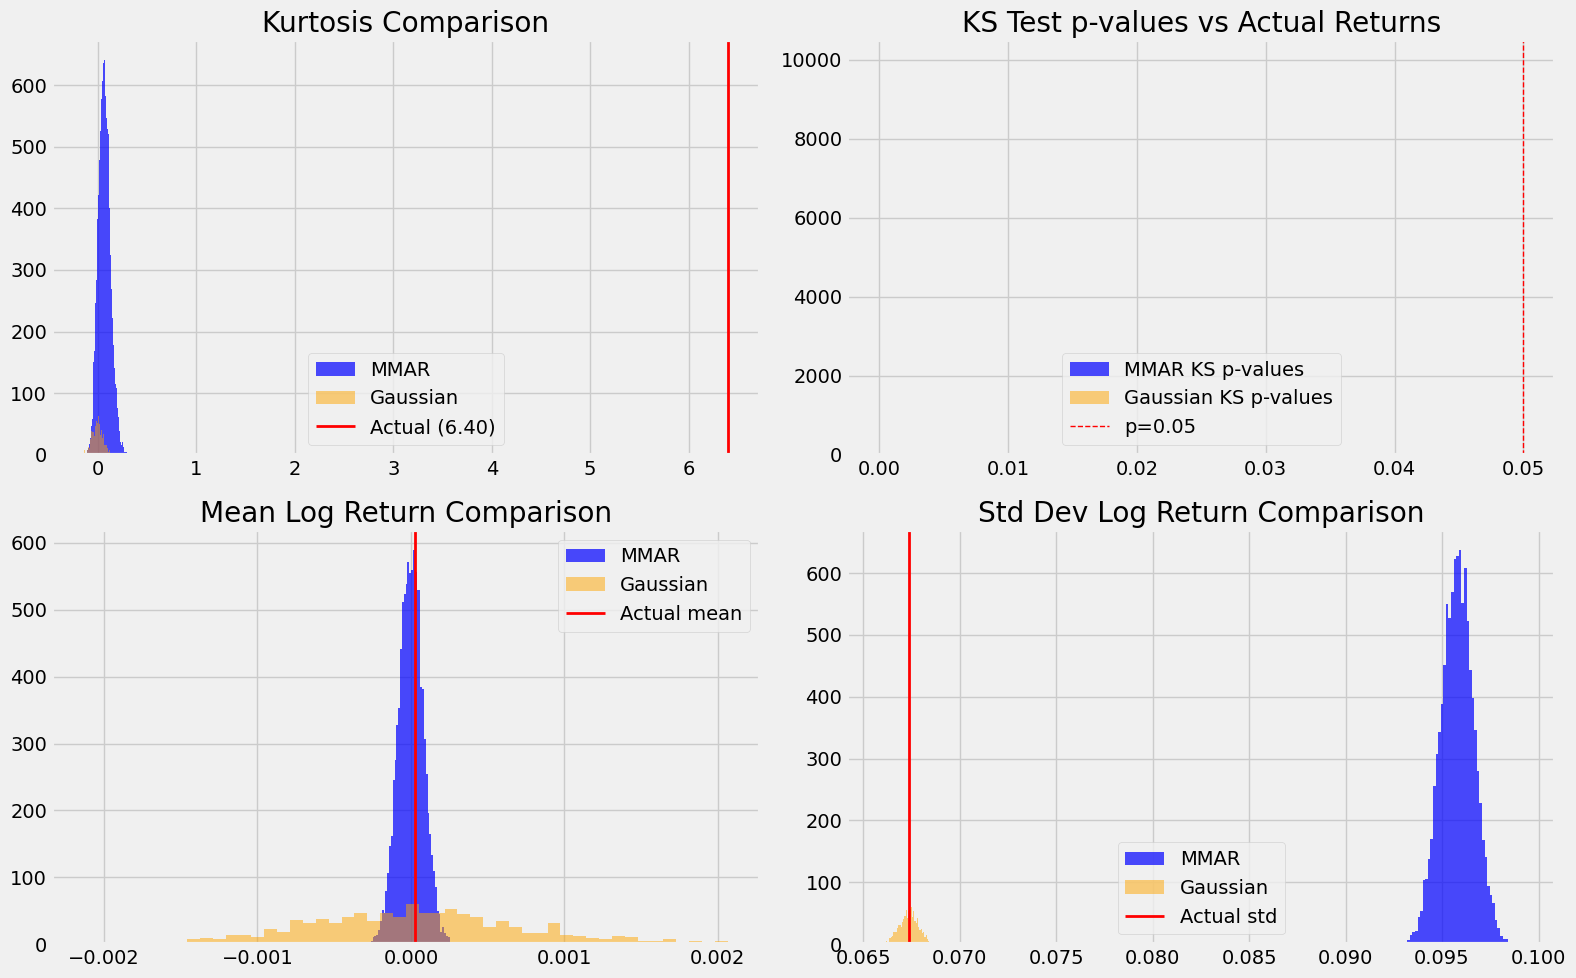

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(kurtosis_MMAR, bins=50, alpha=0.7, color='blue', label='MMAR')
axes[0, 0].hist(kurtosis_Gaussian, bins=50, alpha=0.5, color='orange', label='Gaussian')
axes[0, 0].axvline(real_kurtosis, color='red', linewidth=2, label=f'Actual ({real_kurtosis:.2f})')
axes[0, 0].set_title('Kurtosis Comparison')
axes[0, 0].legend()

axes[0, 1].hist(ks_test_VIX, bins=50, alpha=0.7, color='blue', label='MMAR KS p-values')
axes[0, 1].hist(ks_test_Gaussian_VIX, bins=50, alpha=0.5, color='orange', label='Gaussian KS p-values')
axes[0, 1].axvline(0.05, color='red', linewidth=1, linestyle='--', label='p=0.05')
axes[0, 1].set_title('KS Test p-values vs Actual Returns')
axes[0, 1].legend()

MMAR_means = diff_attempt.mean(axis=0)
Gaussian_means = Gaussian_diff_attempt.mean(axis=0)
axes[1, 0].hist(MMAR_means, bins=50, alpha=0.7, color='blue', label='MMAR')
axes[1, 0].hist(Gaussian_means, bins=50, alpha=0.5, color='orange', label='Gaussian')
axes[1, 0].axvline(log_returns_clean.mean(), color='red', linewidth=2, label=f'Actual mean')
axes[1, 0].set_title('Mean Log Return Comparison')
axes[1, 0].legend()

MMAR_stds = diff_attempt.std(axis=0)
Gaussian_stds = Gaussian_diff_attempt.std(axis=0)
axes[1, 1].hist(MMAR_stds, bins=50, alpha=0.7, color='blue', label='MMAR')
axes[1, 1].hist(Gaussian_stds, bins=50, alpha=0.5, color='orange', label='Gaussian')
axes[1, 1].axvline(log_returns_clean.std(), color='red', linewidth=2, label=f'Actual std')
axes[1, 1].set_title('Std Dev Log Return Comparison')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [36]:
print("=" * 60)
print("FINAL COMPARISON: MMAR vs Gaussian vs Actual")
print("=" * 60)
print(f"{'Metric':<30} {'MMAR':>10} {'Gaussian':>10} {'Actual':>10}")
print("-" * 60)
print(f"{'Mean kurtosis':<30} {np.mean(kurtosis_MMAR):>10.4f} {np.mean(kurtosis_Gaussian):>10.4f} {real_kurtosis:>10.4f}")
print(f"{'Mean log return':<30} {MMAR_means.mean():>10.6f} {Gaussian_means.mean():>10.6f} {log_returns_clean.mean():>10.6f}")
print(f"{'Mean std dev':<30} {MMAR_stds.mean():>10.6f} {Gaussian_stds.mean():>10.6f} {log_returns_clean.std():>10.6f}")
print(f"{'Mean KS p-value':<30} {np.mean(ks_test_VIX):>10.4f} {np.mean(ks_test_Gaussian_VIX):>10.4f} {'—':>10}")
print(f"{'% KS p>0.05':<30} {100*np.mean(np.array(ks_test_VIX)>0.05):>9.1f}% {100*np.mean(np.array(ks_test_Gaussian_VIX)>0.05):>9.1f}% {'—':>10}")
print("=" * 60)
print(f"\nMMar Parameters Used:")
print(f"  H = {H_VIX:.6f}")
print(f"  α₀ = {alpha_0_VIX:.6f}")
print(f"  λ = {lambda_VIX:.6f}")
print(f"  σ² = {sigma_VIX:.6f}")
print(f"  K = {K} ({2**K} days)")
print(f"  MMAR simulations: {attempt_length}")
print(f"  Gaussian simulations: {Gaussian_length}")

FINAL COMPARISON: MMAR vs Gaussian vs Actual
Metric                               MMAR   Gaussian     Actual
------------------------------------------------------------
Mean kurtosis                      0.0671    -0.0030     6.3976
Mean log return                 -0.000000   0.000026   0.000025
Mean std dev                     0.095792   0.067370   0.067368
Mean KS p-value                    0.0000     0.0000          —
% KS p>0.05                          0.0%       0.0%          —

MMar Parameters Used:
  H = 0.214349
  α₀ = 0.206939
  λ = 0.965431
  σ² = -0.099746
  K = 13 (8192 days)
  MMAR simulations: 10000
  Gaussian simulations: 1000
